# **Histogram Equalization**

## **Abstract**

**Histogram Equalization** (HE) is a popular technique in Image Processing that is used to contrast increment on a given image. Since the value of each pixel in a grayscale image lies in the range $[0,255] \cap ℤ^+$ where $0$ denotes a black pixel and $255$ denotes a white pixel, the pixel distribution is discrete, allowing one to easily perform computations based on the pixel values.

<br>

HE simply works by "spreading out" the pixel distribution of an image, so that the resulting image has a uniform pixel distribution, allowing for more significant features to be amplified/contrasted and for the potential reduction in the noise of the overall image. We will start by importing the necessary packages and loading in the image for this project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

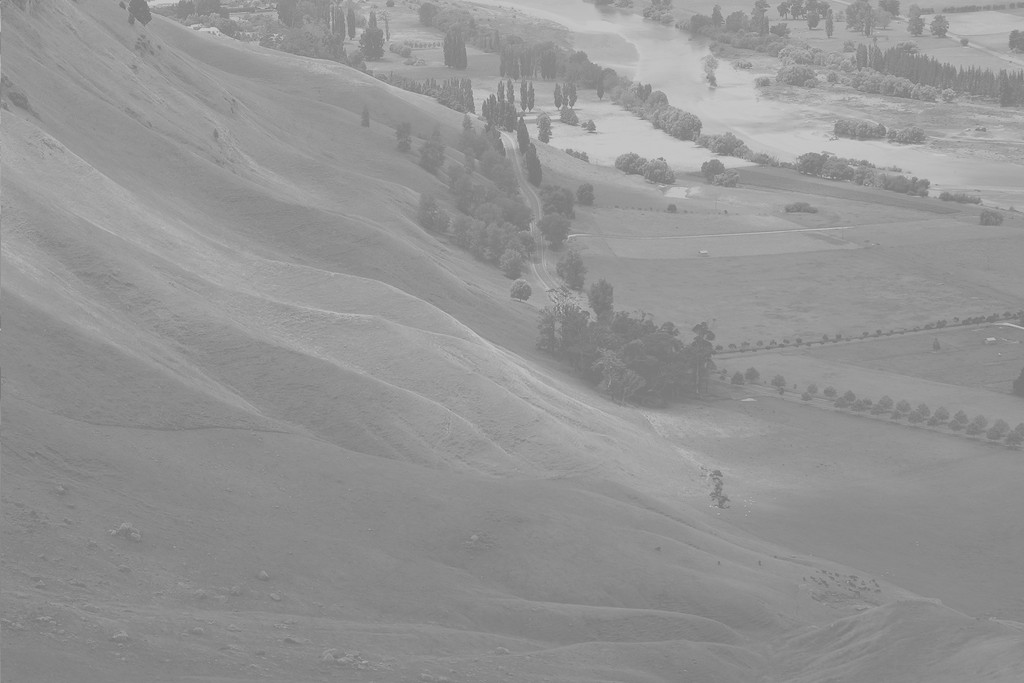

In [2]:
filename = "nature_image.jpg"

# Load in the image using its file and convert it to grayscale if not done yet.
image = Image.open(filename).convert("L")

# Load in the data for each pixel in the image.
pixels = image.load()

# Display the image.
image

## **Pixel Percentiles**

The first feature we must extract about each pixel is its value's percentile in the original image's pixel distribution. Therefore, let us first start by examining the pixel distribution of our image at its original state.

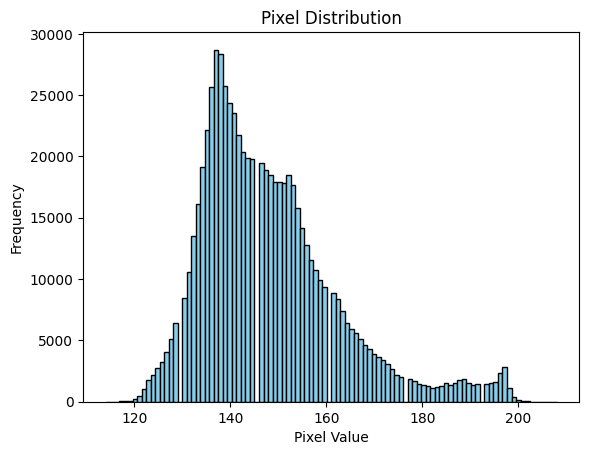

In [3]:
# Initialize an empty array to store each pixel value.
pixel_values = []

# Store the height and width of the image in two variables.
image_width, image_height = image.size

# Initialize variables to keep track of the minimum and maximum pixel values in the image.
min_value = 255
max_value = 0

# Iterate through each pixel and store it in the array of pixel values.
for y in range(image_height):
    for x in range(image_width):
        pixel_values.append(pixels[x, y])

        if pixels[x, y] < min_value:
            min_value = pixels[x, y]

        if pixels[x, y] > max_value:
            max_value = pixels[x, y]

# Plot the pixel distribution.
plt.hist(pixel_values, bins=100, edgecolor='black', color='skyblue')
plt.title("Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Now that we have the distribution of the image, we can calculate the percentile of each pixel value in the original distribution.

In [4]:
# Initialize an empty dictionary to hold the frequency of each pixel value.
frequencies = dict({})

# Initialize an empty dictionary to hold the percentile of each pixel value.
percentiles = dict({})

# Calculate the frequency of each pixel value.
for i in range(len(pixel_values)):
    if pixel_values[i] in frequencies:
        frequencies[pixel_values[i]] += 1
    else:
        frequencies[pixel_values[i]] = 1

# Sort the distinct pixel values in ascending order.
unique_pixels = sorted(frequencies.keys())

# Initialize a variable to keep track of the cumulative frequency.
cumulative_frequency = 0

# Calculate the percentile of each distinct pixel value.
for i in range(len(unique_pixels)):
    cumulative_frequency += frequencies[unique_pixels[i]]
    percentiles[unique_pixels[i]] = cumulative_frequency / len(pixel_values)

## **Pixel Mapping**

Now that we have the percentile value for each distinct pixel value, we can map each pixel value in the image from the original distribution to its corresponding value at that specific percentile in the uniform distribution.

<br>

Assume that $P(x)$ represents the mapping function from a pixel value $x$ $\epsilon$ $[0,255] \cap 𝕎$ to its percentile in the original distribution and that $V$ represents the set of values for each pixel in the image. We can define the function to map a pixel value $\alpha$ from the original distribution to the uniform distribution as such:

$f(\alpha)=[min(V) + max(V)]·P(\alpha)$

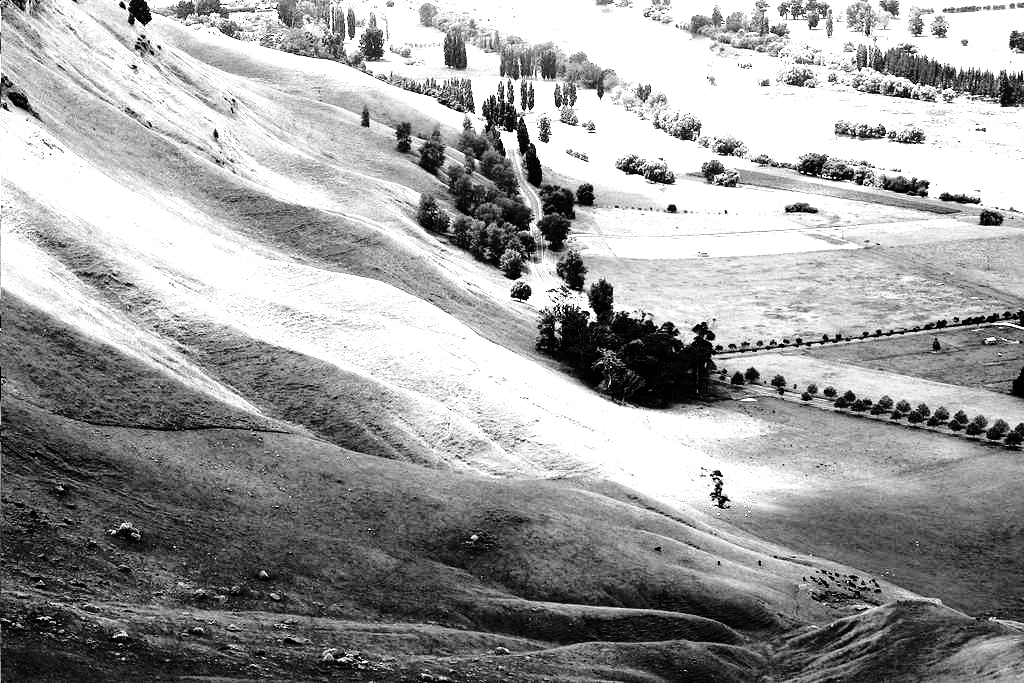

In [5]:
# Re-initialize pixel_values to an empty array to store the new values.
pixel_values = []

# Iterate through the pixels in the image and use the function above to map each
# pixel value from the original distribution to the new distribution.
for y in range(image_height):
    for x in range(image_width):
        pixels[x, y] = int((min_value + max_value) * percentiles[pixels[x, y]])
        pixel_values.append(pixels[x, y])

# Display the image.
image

We can now plot the new distribution of the pixels in the new image.

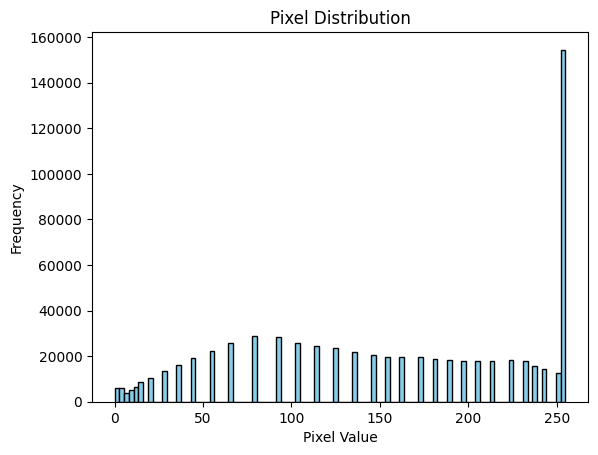

In [6]:
plt.hist(pixel_values, bins=len(percentiles), edgecolor='black', color='skyblue')
plt.title("Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

As we can see, the image above is more clear as its features are more contrasted, and the new distribution of the image is approximately uniform, with the only a few exceptions at the most.